In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

df = pd.read_csv("titanic_cleaned.csv")

print(df.shape)
df.head()

(780, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [2]:
contingency_table = pd.crosstab(df["sex"], df["survived"])

print("Contingency Table:")
print(contingency_table)

Contingency Table:
survived    0    1
sex               
female     76  216
male      382  106


In [3]:
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Test Results")
print("=" * 40)

print("Chi-Square Statistic:", round(chi2, 4))
print("P-value:", p_value)
print("Degrees of Freedom:", degrees_of_freedom)

Chi-Square Test Results
Chi-Square Statistic: 203.6143
P-value: 3.3973191841101995e-46
Degrees of Freedom: 1


In [4]:
alpha = 0.05

print("\nHypothesis Test Decision:")

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant association between gender and survival.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence of a significant association between gender and survival.")


Hypothesis Test Decision:
Reject the null hypothesis.
There is a statistically significant association between gender and survival.


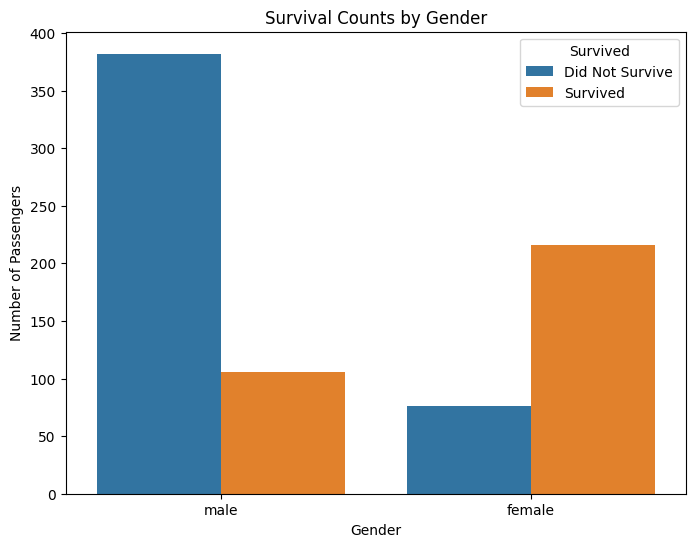

In [5]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="sex",
    hue="survived"
)

plt.title("Survival Counts by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survived",
    labels=["Did Not Survive", "Survived"]
)

plt.show()

In [6]:
survival_rates = (
    df.groupby("sex")["survived"]
      .mean()
      .mul(100)
      .round(2)
)

print("Survival Rate by Gender:")
print(survival_rates)

Survival Rate by Gender:
sex
female    73.97
male      21.72
Name: survived, dtype: float64


In [7]:
n = contingency_table.sum().sum()

cramers_v = np.sqrt(
    chi2 / (n * min(contingency_table.shape[0] - 1,
                    contingency_table.shape[1] - 1))
)

print("Cramer's V:", round(cramers_v, 4))

Cramer's V: 0.5109


In [8]:
print("Expected Frequencies:")
print(pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
).round(2))

Expected Frequencies:
survived       0       1
sex                     
female    171.46  120.54
male      286.54  201.46


In [9]:
print("Minimum Expected Frequency:", expected.min())

Minimum Expected Frequency: 120.54358974358975
